<img src="../../images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Quantitative Precipitation Estimation Model

:::{important} Goal
The goal of this notebook is to showcase a supervised learning technique utilizing ARM disdrometer data to predict quantitative precipitation estimates (QPE).
This workflow requires GPU availability for best performance.
:::

<a href="https://colab.research.google.com/github/ARM-Development/arm-summer-school-2026/blob/main/notebooks/ai-ml/supervised-mlp-ldquants-qpe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

Supervised learning requires paired inputs (X) and targets (Y). For radar quantitative precipitation estimates (QPE), good training pairs are hard to obtain because reliable rain-rate labels are limited. Disdrometer is a ground-based device that measures raindrops concentration and sizes, and calculates what a radar would "see". The key variables are:

- Zh (reflectivity, dBZ):	How strongly radar signal bounces back. More/bigger drops = higher value
- ZDR (differential reflectivity, dB):	Shape of drops. Flatter/bigger drops have higher ZDR
- KDP (specific differential phase, deg/km):	How drops slow the radar signal. Sensitive to high rain rate
- Specific Attenuation:	How much the signal weakens as it travels through rain.


@hardin_ldquants_2019 provides quality controlled drop size distributions from ARM's laser ([LDQUANTS](https://www.arm.gov/publications/tech_reports/doe-sc-arm-tr-221.pdf)) and video disdrometers (VDISQUANTS) value-added products. Utilizing [T-matrix](https://en.wikipedia.org/wiki/T-matrix_method) scattering and additional wavelength, temperature, and drop shape assumptions, both products are well-suited for supervised learning because **they provide radar-like variables derived from drop-size distributions (DSD) along with rain rates for training and testing**.


##### The ML Model: Multi-Layer Perceptron (MLP)
A Multilayer Perceptron ([MLP](https://en.wikipedia.org/wiki/Multilayer_perceptron)) is a type of feedforward artificial neural network. It consists of at least three layers of nodes—an input layer, a hidden layer, and an output layer—where each node (except in the input layer) is a neuron that uses a nonlinear activation function. Each neuron does a weighted sum of its inputs and applies an activation.

This notebook builds and trains a flexible [multilayer perceptron (MLP) regression model](https://en.wikipedia.org/wiki/Multilayer_perceptron) for radar-based quantitative precipitation estimation. It introduces a reusable FlexMLP class with configurable activations and bundled defaults (Adam, MSE, ReduceLROnPlateau) for easy reuse. 

THe MLP regression model utilizes estimated [C-band radar parameters](https://training.weather.gov/nwstc/NEXRAD/RADAR/3-1.htm) from SGP LDQUANTS (@hardin_sgp_ldquants) for training. For validation, utilizing inference load[^inference], the saved model weights from the MLP regression will be used to predict on the AMF-3 [Bankhead National Forest](https://arm.gov/capabilities/observatories/bnf) LDQUANTS (@hardin_bnf_ldquants). 

Because training spans only a few months, adding more historical data should improve the performance of preciptiation estimates within heavy-rain.

[^inference]: The process of running live data points into a trained machine-learning algorithm to calculate an output.

## Prerequisites

| Concepts | Importance | Notes |
| --- | --- | --- |
| [ACT Basics](https://arm-development.github.io/arm-summer-school-2026/act-basics-bnf/) | Necessary | |
| [Scikit-learn](https://scikit-learn.org/stable/) | Helpful | Machine learning library for clustering and preprocessing |
| [PyTorch Tutorials](https://docs.pytorch.org/tutorials/) | Necessary | Machine learning library for building and training deep learning models|

- **Time to learn**: 60 min.
- **System requirements**: pytorch dependency

## Outline

This notebook is organized into **3 main parts**:

- **Part 1: Data Acquisition & Preparation**
  Set up paths, download ARM data from two sites, explore the data and relationships, and preprocessing.

- **Part 2: Model Building, Training & Validation**  
  Build a neural network, understand its hyperparameters, train on SGP data with early stopping, and save the best weights.

- **Part 3: Inference & Validation**
  Load the trained model and test it on independent BNF data to assess generalization.


By the end, you'll understand supervised learning, neural networks, and how to validate on independent data in a real-world meteorological context.

:::{admonition}**If Running these Notebooks on Google CoLab**
You will need to include the Atmospheric data Community Toolkit (ACT) within the python environment.
Uncomment the next line prior to importing the python libraries.
:::

In [12]:
# Uncomment if running on CoLab
##!pip install act-atmos>=2.2.23

Loads all libraries:
- numpy/xarray — data manipulation
- torch — building and training the neural network
- sklearn — for standardization and computing accuracy metrics
- act — Toolkit for downloading and reading ARM data
- matplotlib — plotting

In [13]:
import os
from pathlib import Path
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

# Workarounds for OpenMP + Matplotlib in non-interactive runs
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/matplotlib")))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import act

print("✓ All packages imported successfully")


✓ All packages imported successfully


## Part 1: Data Acquisition & Preparation 
### 1.1 Setup and Download Data from ARM

When prompted, enter your ARM username and token manually.

:::{important} Security Note

Do not share or commit your ARM username or token. Store them in a local shell export, a user-only environment file, or a kernel `env` block outside the repo.
:::

Define quality thresholds. Any observation with reflectivity below 5 dBZ is likely noise (light drizzle or non-precipitation), so it gets filtered out. Same logic for ZDR and KDP — negative values are unphysical for rain.

In [ ]:
# Configuration & data paths
# Ask user for data directory root
data_root = "../../data/"
data_root = Path(data_root).expanduser().absolute()
print(f"Data root: {data_root}")

# Define datastream directories (will be created if they don't exist)
SGP_DIR = data_root / "sgpldquantsC1.c1"
BNF_DIR = data_root / "bnfldquantsM1.c1"

# Create directories
SGP_DIR.mkdir(parents=True, exist_ok=True)
BNF_DIR.mkdir(parents=True, exist_ok=True)
print(f"SGP directory: {SGP_DIR}")
print(f"BNF directory: {BNF_DIR}")

# Data date ranges (adjust as needed)
SGP_START_DATE = "2025-01-01"
SGP_END_DATE = "2025-12-31"
BNF_START_DATE = "2025-11-01"
BNF_END_DATE = "2026-04-08"

# Radar data thresholds (filter low-quality observations)
ZH_THRESHOLD = 5.0
ZDR_THRESHOLD = 0.0
KDP_THRESHOLD = 0.0


Data root: /Users/bhupendra/projects/arm-bnf-amf3/data
SGP directory: /Users/bhupendra/projects/arm-bnf-amf3/data/sgpldquantsC1.c1
BNF directory: /Users/bhupendra/projects/arm-bnf-amf3/data/bnfldquantsM1.c1


#### 1.1.1 Download SGP training data

Skip download if files already exist

In [15]:
# Get ARM credentials from user input
import getpass

# Skip download if files already exist
existing_training = sorted(glob.glob(str(SGP_DIR / "*.nc")))
if len(existing_training) > 0:
    print(f"Found {len(existing_training)} training files in {SGP_DIR}. Skipping download.")
else:
    arm_username = input("Enter ARM username: ").strip()
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

    if not arm_username or not arm_token:
        raise RuntimeError("ARM username/token required to download data.")

    # Download training data
    print(f"Downloading sgpldquantsC1.c1 from {SGP_START_DATE} to {SGP_END_DATE}...")
    try:
        training_files = act.discovery.download_arm_data(
            arm_username,
            arm_token,
            "sgpldquantsC1.c1",
            SGP_START_DATE,
            SGP_END_DATE,
            output=str(SGP_DIR)
        )
        print(f"✓ Downloaded {len(training_files) if isinstance(training_files, list) else '?'} files to {SGP_DIR}")
    except Exception as e:
        print(f" Download may have encountered an issue: {e}")
        print(f"   Continuing... Check that files exist in {SGP_DIR}")


Found 362 training files in /Users/bhupendra/projects/arm-bnf-amf3/data/sgpldquantsC1.c1. Skipping download.


#### 1.1.2 Download BNF validation data

In [16]:
existing_bnf = sorted(glob.glob(str(BNF_DIR / "*.nc")))
if len(existing_bnf) > 0:
    print(f"Found {len(existing_bnf)} BNF files in {BNF_DIR}. Skipping download.")
else:
    # Reuse credentials from training download, or prompt if missing
    if 'arm_username' not in globals() or 'arm_token' not in globals():
        import getpass
        arm_username = input("Enter ARM username: ").strip()
        arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

    print(f"Downloading bnfldquantsM1.c1 from {BNF_START_DATE} to {BNF_END_DATE}...")
    try:
        bnf_files = act.discovery.download_arm_data(
            arm_username,
            arm_token,
            "bnfldquantsM1.c1",
            BNF_START_DATE,
            BNF_END_DATE,
            output=str(BNF_DIR)
        )
        print(f"✓ Downloaded {len(bnf_files) if isinstance(bnf_files, list) else '?'} files to {BNF_DIR}")
    except Exception as e:
        print(f"⚠ Download may have encountered an issue: {e}")
        print(f"   Continuing... Check that files exist in {BNF_DIR}")


Found 228 BNF files in /Users/bhupendra/projects/arm-bnf-amf3/data/bnfldquantsM1.c1. Skipping download.


### 1.2 Filter & Clean Data

Remove very low rain/reflecitivty observations before analysis.

In [17]:
# Load all training data files using xarray
training_files = sorted(glob.glob(str(SGP_DIR / "*.nc")))
print(f"Found {len(training_files)} training data files")

if len(training_files) > 0:
    # Load dataset
    ds_training_raw = xr.open_mfdataset(training_files, combine='nested', concat_dim='time')
    print(f"Training Dataset dimensions: {dict(ds_training_raw.dims)}")
    print(f"Training Dataset variables: {list(ds_training_raw.data_vars)}")

    # Apply quality thresholds (filter low-quality observations)
    qc_mask = (
        (ds_training_raw['reflectivity_factor_cband20c'] > ZH_THRESHOLD) &
        (ds_training_raw['differential_reflectivity_cband20c'] >= ZDR_THRESHOLD) &
        (ds_training_raw['specific_differential_phase_cband20c'] >= KDP_THRESHOLD)
    )
    ds_training_qc = ds_training_raw.where(qc_mask)
else:
    raise RuntimeError(
        "No training .nc files found. Set ARM_USERNAME/ARM_PASSWORD to download, "
        f"or place files in {SGP_DIR}."
    )


Found 362 training data files


/var/folders/c0/hb5cyy892hqdjht868lw3qk80000gp/T/ipykernel_39525/1598926314.py:8: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Training Dataset dimensions: {dict(ds_training_raw.dims)}")


Training Dataset dimensions: {'time': 512236}
Training Dataset variables: ['base_time', 'time_offset', 'rain_rate', 'reflectivity_factor_sband20c', 'reflectivity_factor_cband20c', 'reflectivity_factor_xband20c', 'reflectivity_factor_kaband20c', 'reflectivity_factor_wband20c', 'differential_reflectivity_sband20c', 'differential_reflectivity_cband20c', 'differential_reflectivity_xband20c', 'differential_reflectivity_kaband20c', 'specific_differential_phase_sband20c', 'specific_differential_phase_cband20c', 'specific_differential_phase_xband20c', 'specific_differential_phase_kaband20c', 'specific_attenuation_sband20c', 'specific_attenuation_cband20c', 'specific_attenuation_xband20c', 'specific_attenuation_kaband20c', 'gammapsd_slope', 'gammapsd_shape', 'num_concen', 'norm_num_concen', 'med_diameter', 'mass_weighted_mean_diameter', 'lwc', 'total_droplet_concentration', 'exppsd_slope', 'mean_doppler_vel_sband20c', 'mean_doppler_vel_cband20c', 'mean_doppler_vel_xband20c', 'mean_doppler_vel_k

### 1.3 Explore Data

It is recommended to do detail analysis before any AI/ML study. Therefore, we will plot variable distributions or their relationships to understand the radar variables. 

Note: The dataset contains variables for  many radar-bands. We will use C-band.

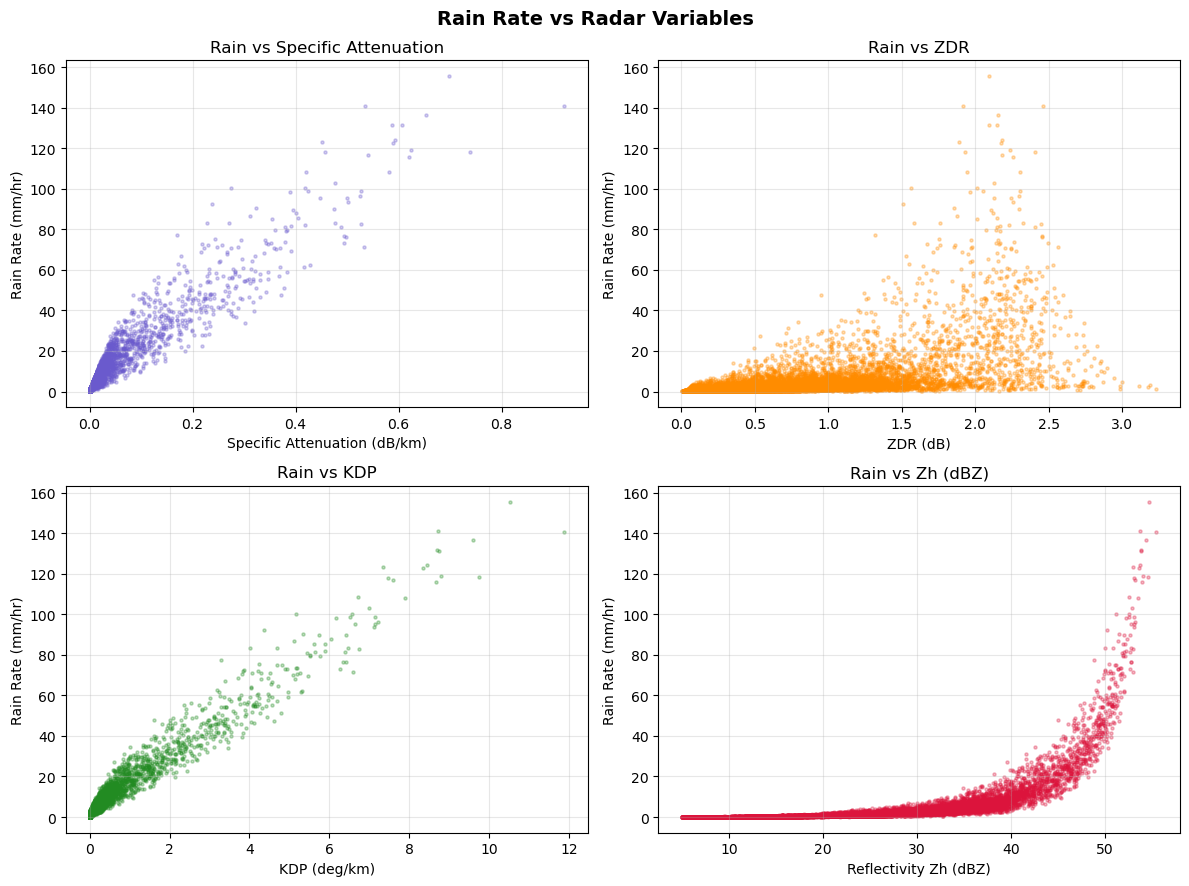

✓ plots created successfully


In [18]:
if "ds_training_qc" in globals():
    # Plot rain rate vs key input variables
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle('Rain Rate vs Radar Variables', fontsize=14, fontweight='bold')

    # Helper to downsample for faster plotting
    def _sample_xy(x, y, max_n=20000):
        mask = ~np.isnan(x) & ~np.isnan(y)
        x = x[mask]
        y = y[mask]
        if len(x) > max_n:
            idx = np.random.choice(len(x), size=max_n, replace=False)
            x = x[idx]
            y = y[idx]
        return x, y

    # Rain rate
    if 'rain_rate' in ds_training_qc:
        rain = ds_training_qc['rain_rate'].values.flatten()
    else:
        raise RuntimeError('rain_rate not found in training dataset')

    # 1) Specific attenuation
    if 'specific_attenuation_cband20c' in ds_training_qc:
        attn = ds_training_qc['specific_attenuation_cband20c'].values.flatten()
        x, y = _sample_xy(attn, rain)
        axes[0, 0].scatter(x, y, s=5, alpha=0.3, color='slateblue')
        axes[0, 0].set_xlabel('Specific Attenuation (dB/km)')
        axes[0, 0].set_ylabel('Rain Rate (mm/hr)')
        axes[0, 0].set_title('Rain vs Specific Attenuation')
        axes[0, 0].grid(alpha=0.3)
    else:
        axes[0, 0].set_title('Specific Attenuation not found')
        axes[0, 0].axis('off')

    # 2) ZDR
    if 'differential_reflectivity_cband20c' in ds_training_qc:
        zdr = ds_training_qc['differential_reflectivity_cband20c'].values.flatten()
        x, y = _sample_xy(zdr, rain)
        axes[0, 1].scatter(x, y, s=5, alpha=0.3, color='darkorange')
        axes[0, 1].set_xlabel('ZDR (dB)')
        axes[0, 1].set_ylabel('Rain Rate (mm/hr)')
        axes[0, 1].set_title('Rain vs ZDR')
        axes[0, 1].grid(alpha=0.3)
    else:
        axes[0, 1].set_title('ZDR not found')
        axes[0, 1].axis('off')

    # 3) KDP
    if 'specific_differential_phase_cband20c' in ds_training_qc:
        kdp = ds_training_qc['specific_differential_phase_cband20c'].values.flatten()
        x, y = _sample_xy(kdp, rain)
        axes[1, 0].scatter(x, y, s=5, alpha=0.3, color='forestgreen')
        axes[1, 0].set_xlabel('KDP (deg/km)')
        axes[1, 0].set_ylabel('Rain Rate (mm/hr)')
        axes[1, 0].set_title('Rain vs KDP')
        axes[1, 0].grid(alpha=0.3)
    else:
        axes[1, 0].set_title('KDP not found')
        axes[1, 0].axis('off')

    # 4) Reflectivity (DbZ / Zh)
    if 'reflectivity_factor_cband20c' in ds_training_qc:
        zh = ds_training_qc['reflectivity_factor_cband20c'].values.flatten()
        x, y = _sample_xy(zh, rain)
        axes[1, 1].scatter(x, y, s=5, alpha=0.3, color='crimson')
        axes[1, 1].set_xlabel('Reflectivity Zh (dBZ)')
        axes[1, 1].set_ylabel('Rain Rate (mm/hr)')
        axes[1, 1].set_title('Rain vs Zh (dBZ)')
        axes[1, 1].grid(alpha=0.3)
    else:
        axes[1, 1].set_title('Reflectivity not found')
        axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()
    print("✓ plots created successfully")
else:
    print("Cannot create plots: no data files loaded")


All 4 variables have a positive correlation with rain rate The datapoints for higher rainrates are fewer. The relationship of all the variables with rainrate has significant scatter. Together they can provide better estimates of rain rate.

### 1.4 Preprocessing data
This cell defines 3 reusable functions. Think of them as a pipeline:
Functions to Rename variables, apply thresholds, standardize features, and build DataLoaders. We will use them later during training and testing.

In [19]:
from pathlib import Path

# Map dataset variable names to friendly short names (variable renaming)
VARIABLES_MAP = {
    'reflectivity_factor_cband20c': 'zh',
    'differential_reflectivity_cband20c': 'zdr',
    'specific_differential_phase_cband20c': 'kdp',
    'specific_attenuation_cband20c': 'specific_attenuation',
    'gammapsd_shape': 'mu',
    'med_diameter': 'd0',
    'norm_num_concen': 'nw',
    'rain_rate': 'rainrate',
}

def load_dataset(data_dir):
    """Load and merge all NetCDF files from a directory."""
    files = sorted(Path(data_dir).glob('*.nc'))
    if not files:
        raise FileNotFoundError(f'No .nc files found in {data_dir}')
    ds = xr.open_mfdataset(files, combine='nested', concat_dim='time')
    return ds.rename(VARIABLES_MAP)

def filter_to_numpy(ds, input_features, target_features, zh_threshold=5.0, zdr_threshold=0.0, kdp_threshold=0.0):
    """Apply QC thresholds and convert to NumPy arrays."""
    # Rename if dataset still has raw ARM variable names
    if not set(input_features + target_features).issubset(ds.data_vars):
        ds = ds.rename(VARIABLES_MAP)

    ds = ds[input_features + target_features]
    # Apply quality thresholds
    mask = (ds['zh'] > zh_threshold) & (ds['zdr'] >= zdr_threshold) & (ds['kdp'] >= kdp_threshold)
    ds = ds.where(mask)
    df = ds.to_dataframe().dropna()
    if df.empty:
        raise ValueError('No valid samples after filtering.')
    X = df[input_features].to_numpy().astype('float32')
    Y = df[target_features].to_numpy().astype('float32')
    return X, Y


Features are scaled to mean=0, std=1. Without this, Zh (values like 30 dBZ) would dominate over KDP (values like 0.5 deg/km) just because of scale.

Note: This function wraps everything in PyTorch DataLoaders that feed the model in mini-batches during training.

In [20]:

def split_scale_to_loaders(X, Y, train_ratio=0.8, batch_size=16, seed=42):
    """Split data, standardize, and create DataLoaders."""
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    split = max(1, int(len(X) * train_ratio))
    split = min(split, len(X) - 1)
    train_idx, val_idx = idx[:split], idx[split:]

    X_train, X_val = X[train_idx], X[val_idx]
    Y_train, Y_val = Y[train_idx], Y[val_idx]

    # Fit standardization on training set only (prevent data leakage)
    mean_X, std_X = X_train.mean(axis=0), X_train.std(axis=0)
    std_X[std_X == 0] = 1  # Avoid division by zero
    mean_Y, std_Y = Y_train.mean(axis=0), Y_train.std(axis=0)
    std_Y[std_Y == 0] = 1

    # Apply standardization to both train and validation
    X_train = (X_train - mean_X) / std_X
    X_val = (X_val - mean_X) / std_X
    Y_train = (Y_train - mean_Y) / std_Y
    Y_val = (Y_val - mean_Y) / std_Y

    # Create DataLoaders
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(Y_train))
    val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(Y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, {"mean_X": mean_X, "std_X": std_X, "mean_Y": mean_Y, "std_Y": std_Y}

print("✓ Data loading functions defined")


✓ Data loading functions defined


---

## Part 2: Model Building, Training & Validation

We now build the neural network, review hyperparameters, and train the model.

### 2.1 FlexMLP Neural Network Class

This class defines a flexible Multi-Layer Perceptron with the following features:
- **Configurable architecture**: Input → Hidden Layers → Output
- **Bundled defaults**: Uses Adam optimizer, MSE loss, and adaptive learning rate scheduler (ReduceLROnPlateau)
- **Auto device detection**: Automatically uses GPU if available; otherwise CPU

You don't need to understand every line of this class, but you should understand the parameters given to the class in the following cells.

In [21]:
class FlexMLP(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dims,
        output_dim,
        activation_fn='relu',
        dropout=0.0,
        use_batchnorm=False,
        optimizer_name='adam',
        learning_rate=1e-3,
        loss_name='mseloss',
        scheduler_patience=2,
        scheduler_factor=0.5,
        device=None,
    ):
        super().__init__()
        self.device = device or self._detect_device()
        print(f'Using device: {self.device}')
        layers = []

        act_cls = self._resolve_activation(activation_fn)

        all_dims = [input_dim] + hidden_dims
        for i in range(len(hidden_dims)):
            layers.append(nn.Linear(all_dims[i], all_dims[i + 1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(all_dims[i + 1]))
            layers.append(act_cls())
            if dropout > 0.0:
                layers.append(nn.Dropout(p=dropout))

        layers.append(nn.Linear(hidden_dims[-1], output_dim))
        self.net = nn.Sequential(*layers).to(self.device)

        self.loss_fn = self._resolve_loss(loss_name)
        opt_cls = self._resolve_optimizer(optimizer_name)
        opt_kwargs = {'lr': learning_rate}
        if opt_cls is optim.SGD:
            opt_kwargs['momentum'] = 0.9
        self.optimizer = opt_cls(self.parameters(), **opt_kwargs)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='min', patience=scheduler_patience, factor=scheduler_factor)

    def _detect_device(self):
        if torch.cuda.is_available():
            return torch.device('cuda')
        if torch.backends.mps.is_available():
            return torch.device('mps')
        return torch.device('cpu')

    def _resolve_activation(self, activation_fn):
        if isinstance(activation_fn, str):
            key = activation_fn.lower()
            mapping = {
                'relu': nn.ReLU,
                'tanh': nn.Tanh,
                'sigmoid': nn.Sigmoid,
                'leakyrelu': nn.LeakyReLU,
                'gelu': nn.GELU,
                'elu': nn.ELU,
                'selu': nn.SELU,
                'softplus': nn.Softplus,
            }
            if key not in mapping:
                raise ValueError('Unsupported activation: ' + activation_fn)
            return mapping[key]
        if issubclass(activation_fn, nn.Module):
            return activation_fn
        raise TypeError('activation_fn must be a string name or nn.Module class')

    def _resolve_optimizer(self, name):
        mapping = {
            'adam': optim.Adam,
            'adamw': optim.AdamW,
            'sgd': optim.SGD,
            'rmsprop': optim.RMSprop,
        }
        key = name.lower()
        if key not in mapping:
            raise ValueError('Unsupported optimizer: ' + name)
        return mapping[key]

    def _resolve_loss(self, name):
        mapping = {
            'mseloss': nn.MSELoss(),
            'mse': nn.MSELoss(),
            'maeloss': nn.L1Loss(),
            'mae': nn.L1Loss(),
            'huberloss': nn.HuberLoss(),
            'smoothl1loss': nn.SmoothL1Loss(),
        }
        key = name.lower()
        if key not in mapping:
            raise ValueError('Unsupported loss: ' + name)
        return mapping[key]

    def forward(self, x):
        return self.net(x)


### 2.2 Understanding Model Hyperparameters

Before training, let's understand the hyperparameters

| Parameter | Value | Explanation |
|-----------|-------|-------------|
| **hidden_dims** | [256, 128, 64, 32] | Network layer sizes. Each layer progressively gets smaller to avoid overfitting. |
| **activation_fn** | 'relu' | Activation function (Use `relu` and you can also try `sigmoid`). Which of them is fast and works well for regression tasks. |
| **dropout** | 0.2 | Randomly disable 20% of neurons during training to prevent overfitting. |
| **learning_rate** | 1e-3 | Step size for weight updates. Too high = unstable; too low = slow convergence. |
| **batch_size** | 16 | Process 16 samples per gradient update. Small batch = noisy updates; large batch = slower but stable. |
| **epochs** | 50 | Train for up to 50 passes through the dataset. Early stopping may end sooner. |
| **early_stop_patience** | 5 | Stop training if validation loss doesn't improve for 5 consecutive epochs. |

**Tip**: Try changing these values to see how they affect training (e.g., larger learning_rate → faster but riskier, smaller batch_size → more frequent updates).

##### Set Hyperparameters

In [22]:
# Model configuration
INPUT_FEATURES = ['zh', 'zdr', 'kdp', 'specific_attenuation']
TARGET_FEATURES = ['rainrate']

# Hyperparameters
HIDDEN_DIMS = [256, 128, 64, 32]
ACTIVATION_FN = 'relu'
DROPOUT = 0.2
USE_BATCHNORM = True
LEARNING_RATE = 1e-3
BATCH_SIZE = 16
EPOCHS = 50
EARLY_STOP_PATIENCE = 5
TRAIN_RATIO = 0.8

# File paths for model & results
MODEL_WEIGHTS_FILE = Path("mlp_radar_qpe_weights.pt")
print(f"We will save model to: {MODEL_WEIGHTS_FILE}")


We will save model to: mlp_radar_qpe_weights.pt


### 2.3 Load & Preprocess Training Data

Load training data, apply quality thresholds, standardize, and prepare for training. Using funcrions from 1.4


In [23]:
# Load training data, apply quality thresholds, standardize, and prepare for training.

# Preprocess training data
print("=" * 70)
print("PREPROCESSING TRAINING DATA")
print("=" * 70)

# Load, filter, and standardize TRAINING data
print("\n1. Loading TRAINING data from trained files...")
X_train_raw, Y_train_raw = filter_to_numpy(ds_training_qc, INPUT_FEATURES, TARGET_FEATURES)
print(f"   Loaded {len(X_train_raw)} raw samples")

print("\n2. Splitting into train/validation...")
train_loader, val_loader, scalers = split_scale_to_loaders(
    X_train_raw, 
    Y_train_raw, 
    train_ratio=TRAIN_RATIO,
    batch_size=BATCH_SIZE,
    seed=42
)
print(f"   Train batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
feature_scaler = {"mean": scalers["mean_X"], "std": scalers["std_X"]}
target_scaler = {"mean": scalers["mean_Y"], "std": scalers["std_Y"]}
print(f"   Target (rain rate) standardization: mean={target_scaler['mean'][0]:.2f}, std={target_scaler['std'][0]:.2f}")


PREPROCESSING TRAINING DATA

1. Loading TRAINING data from trained files...
   Loaded 14145 raw samples

2. Splitting into train/validation...
   Train batches: 708
   Validation batches: 177
   Target (rain rate) standardization: mean=3.86, std=9.77


We scale the data using these values, so after the inference we convert them to mm/hr.

In [24]:

# ===== INSTANTIATE MODEL =====
print("\n3. Creating FlexMLP model...")
model = FlexMLP(
    input_dim=len(INPUT_FEATURES),
    hidden_dims=HIDDEN_DIMS,
    output_dim=len(TARGET_FEATURES),
    activation_fn=ACTIVATION_FN,
    dropout=DROPOUT,
    use_batchnorm=USE_BATCHNORM,
    optimizer_name='adam',
    learning_rate=LEARNING_RATE,
    loss_name='mseloss',
    scheduler_patience=2,
    scheduler_factor=0.5,
    device=None,  # Auto-detect GPU/CPU
)
print(f"   ✓ Model created with {sum(p.numel() for p in model.parameters())} parameters")


3. Creating FlexMLP model...
Using device: mps
   ✓ Model created with 45505 parameters


### 2.4 Training the Model with Early Stopping

The training loop below performs the following steps each epoch:
1. **Forward pass**: Send training data through the network to get predictions
2. **Compute loss**: Measure prediction error (MSE = Mean Squared Error)
3. **Backward pass**: Calculate gradients via backpropagation
4. **Update weights**: Adjust weights using Adam optimizer
5. **Validate**: Check performance on held-out validation set
6. **Early stopping**: Save best model and stop if validation loss plateaus

This process repeats for up to EPOCHS passes or until early stopping is triggered.

In [25]:
print("=" * 70)
print("STARTING TRAINING")
print("=" * 70)

epochs = EPOCHS
best_val_loss = np.inf
patience = EARLY_STOP_PATIENCE
patience_counter = 0

for epoch in range(epochs):
    # ===== TRAINING PHASE =====
    model.train()  # Enable dropout and batch norm for training
    train_loss = 0
    
    for X_batch, y_batch in train_loader:
        # Move batches to GPU/CPU device
        X_batch, y_batch = X_batch.to(model.device), y_batch.to(model.device)
        
        # FORWARD PASS: Network prediction
        preds = model(X_batch)
        
        # LOSS CALCULATION: Measure prediction error (MSE)
        loss = model.loss_fn(preds, y_batch)
        
        # BACKWARD PASS: Calculate gradients
        model.optimizer.zero_grad()  # Clear old gradients
        loss.backward()               # Compute new gradients via backpropagation
        
        # WEIGHT UPDATE: Apply gradients to update network weights
        model.optimizer.step()
        
        train_loss += loss.item()
    
    # ===== VALIDATION PHASE =====
    model.eval()  # Disable dropout and batch norm for validation
    val_loss = 0
    with torch.no_grad():  # Don't compute gradients (saves memory)
        for X_val, y_val in val_loader:
            X_val, y_val = X_val.to(model.device), y_val.to(model.device)
            val_preds = model(X_val)
            val_loss += model.loss_fn(val_preds, y_val).item()
    
    # Average loss over all batches
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    # LEARNING RATE SCHEDULING: Reduce LR if val_loss plateaus
    model.scheduler.step(avg_val_loss)
    
    print(f'Epoch {epoch + 1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}', end='')
    
    # ===== EARLY STOPPING =====
    if avg_val_loss < best_val_loss:
        # New best validation loss found
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), str(MODEL_WEIGHTS_FILE))
        print(" ← BEST")
    else:
        # Validation loss did not improve
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n\nEarly stopping triggered at epoch {epoch + 1}.")
            print(f"Validation loss plateaued. Best val loss: {best_val_loss:.4f}")
            break
        else:
            print()

print("=" * 70)
print("TRAINING COMPLETE")
print(f"Model weights saved to: {MODEL_WEIGHTS_FILE}")
print("=" * 70)


STARTING TRAINING
Epoch   1/50 | Train Loss: 0.3184 | Val Loss: 0.1734 ← BEST
Epoch   2/50 | Train Loss: 0.1851 | Val Loss: 0.0355 ← BEST
Epoch   3/50 | Train Loss: 0.1326 | Val Loss: 0.0395
Epoch   4/50 | Train Loss: 0.1091 | Val Loss: 0.0728
Epoch   5/50 | Train Loss: 0.0963 | Val Loss: 0.1136
Epoch   6/50 | Train Loss: 0.0828 | Val Loss: 0.0928
Epoch   7/50 | Train Loss: 0.0786 | Val Loss: 0.1095

Early stopping triggered at epoch 7.
Validation loss plateaued. Best val loss: 0.0355
TRAINING COMPLETE
Model weights saved to: mlp_radar_qpe_weights.pt


### 2.5 Save the Model

During training, we saved the best model weights (when validation loss was lowest). We save only the weights (`state_dict`), not the entire object. This avoid compatibility issue of Pytorch versions but we need to create the same model again.

The weights have been saved to MODEL_WEIGHTS_FILE. Next, we'll load these weights to make predictions on validation data.

In [26]:
# Model weights have been automatically saved to MODEL_WEIGHTS_FILE during training
# (saved after each epoch when validation loss improved)
print(f"✓ Model weights saved to: {MODEL_WEIGHTS_FILE}")
print(f"  File exists: {MODEL_WEIGHTS_FILE.exists()}")


✓ Model weights saved to: mlp_radar_qpe_weights.pt
  File exists: True


---

## Part 3: Inference & Validation

In this section, we load the trained model and validate it on independent data from the BNF site.

### 3.1 Inference & Validation on Independent Data (BNF)

Test the trained model on data from the BNF site. This demonstrates whether the model generalizes to independent observations from a different location. 


First, let's standardize BNF inputs using the training set's mean/std — not BNF's own stats. This is critical: the model was trained on SGP-scaled data, so you must apply the same transformation

In [27]:
print("=" * 70)
print("INFERENCE ON VALIDATION DATA (BNF)")
print("=" * 70)

# ===== STEP 1: Load Validation Data from BNF =====
print("\n1. Loading BNF validation data...")
bnf_files = sorted(glob.glob(str(BNF_DIR / "*.nc")))
print(f"   Found {len(bnf_files)} BNF files")

if len(bnf_files) > 0:
    # Load dataset
    ds_bnf = xr.open_mfdataset(bnf_files, combine='nested', concat_dim='time')
    print(f"   Dimensions: {dict(ds_bnf.dims)}")
    
    # Apply same quality thresholds as training
    mask = (ds_bnf['reflectivity_factor_cband20c'] > ZH_THRESHOLD) & \
           (ds_bnf['differential_reflectivity_cband20c'] >= ZDR_THRESHOLD) & \
           (ds_bnf['specific_differential_phase_cband20c'] >= KDP_THRESHOLD)
    ds_bnf = ds_bnf.where(mask)
    
    # Rename variables
    ds_bnf = ds_bnf.rename({
        'reflectivity_factor_cband20c': 'zh',
        'differential_reflectivity_cband20c': 'zdr',
        'specific_differential_phase_cband20c': 'kdp',
        'specific_attenuation_cband20c': 'specific_attenuation',
        'rain_rate': 'rainrate',
    })
    
    # Convert to numpy
    df_bnf = ds_bnf[INPUT_FEATURES + TARGET_FEATURES].to_dataframe().dropna()
    X_bnf = df_bnf[INPUT_FEATURES].to_numpy().astype('float32')
    Y_bnf = df_bnf[TARGET_FEATURES].to_numpy().astype('float32')
    print(f"   After QC filtering: {len(X_bnf)} valid samples")
else:
    print("⚠ No BNF files found. Skipping inference.")
    X_bnf = None
    Y_bnf = None


INFERENCE ON VALIDATION DATA (BNF)

1. Loading BNF validation data...
   Found 228 BNF files


/var/folders/c0/hb5cyy892hqdjht868lw3qk80000gp/T/ipykernel_39525/1906513253.py:13: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"   Dimensions: {dict(ds_bnf.dims)}")


   Dimensions: {'time': 323241}
   After QC filtering: 15919 valid samples


Run the forward pass — no training, just prediction

In [37]:

# ===== STEP 2: Load Trained Model Weights =====
print("\n2. Loading trained model...")
infer_device = torch.device('cuda' if torch.cuda.is_available() else 
                            'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"   Using device: {infer_device}")

# Recreate model architecture (must match training configuration)
model_inference = FlexMLP(
    input_dim=len(INPUT_FEATURES),
    hidden_dims=HIDDEN_DIMS,
    output_dim=len(TARGET_FEATURES),
    activation_fn=ACTIVATION_FN,
    dropout=DROPOUT,
    use_batchnorm=USE_BATCHNORM,
    optimizer_name='adam',
    learning_rate=LEARNING_RATE,
    loss_name='mseloss',
    scheduler_patience=2,
    scheduler_factor=0.5,
    device=infer_device,
)

# Load saved weights
if MODEL_WEIGHTS_FILE.exists():
    state = torch.load(str(MODEL_WEIGHTS_FILE), map_location=infer_device)
    model_inference.load_state_dict(state)
    print(f"   ✓ Loaded weights from {MODEL_WEIGHTS_FILE}")
else:
    print(f"   ⚠ No saved weights found at {MODEL_WEIGHTS_FILE}")

model_inference.eval()  # Set to evaluation mode (disable dropout/batchnorm)



2. Loading trained model...
   Using device: mps
Using device: mps
   ✓ Loaded weights from mlp_radar_qpe_weights.pt


FlexMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.2, inplace=False)
    (16): Linear(in_features=32, out_features=1, bias=True)
  )
  (loss_fn): MSELoss()
)

In [33]:

# ===== STEP 3: Batch Predictions =====
# Note: We use training-set scalers for fair evaluation (no BNF-based scaling).

print("\n3. Generating predictions...")

# Standardize input data using training-set statistics
X_bnf_std = (X_bnf - feature_scaler["mean"]) / feature_scaler["std"]

preds_list = []
targets_list = []

with torch.no_grad():  # Disable gradient computation (saves memory)
    # Process in batches
    for i in range(0, len(X_bnf_std), BATCH_SIZE):
        X_batch = X_bnf_std[i:i+BATCH_SIZE]
        y_batch = Y_bnf[i:i+BATCH_SIZE]

        # Convert to tensors and move to device
        X_tensor = torch.tensor(X_batch, dtype=torch.float32).to(infer_device)

        # Forward pass (get prediction from network)
        pred_tensor = model_inference(X_tensor)

        # Move back to CPU and convert to numpy
        preds_list.append(pred_tensor.cpu().numpy())
        targets_list.append(y_batch)

# Concatenate all batch predictions
preds_standardized = np.vstack(preds_list)
targets_raw = np.vstack(targets_list)

print(f"   ✓ Generated {len(preds_standardized)} predictions")






3. Generating predictions...
   ✓ Generated 15919 predictions


Note: To De-standardize the output we multiply by training rain rate std and add mean to get back to mm/hr

In [34]:
# ===== STEP 4: Denormalization (Rescale to Original Units) =====
print("\n4. Rescaling predictions to original units...")
print("   Note: Network was trained on standardized targets (mean=0, std=1).")
print("   Using training-set target scalers for de-standardization.")

preds_unscaled = preds_standardized * target_scaler["std"] + target_scaler["mean"]
targets_unscaled = targets_raw  # already in original units

print(f"   Denormalization formula: rescaled = pred * {target_scaler['std'][0]:.2f} + {target_scaler['mean'][0]:.2f}")
print("   ✓ Predictions rescaled to mm/hr")


4. Rescaling predictions to original units...
   Note: Network was trained on standardized targets (mean=0, std=1).
   Using training-set target scalers for de-standardization.
   Denormalization formula: rescaled = pred * 9.77 + 3.86
   ✓ Predictions rescaled to mm/hr


Two plots are generated:

1. Scatter plot (predicted vs observed): points near the red line are good predictions
2. Residuals histogram: centered near zero means unbiased and narrow histogram means more precise.


5. Computing performance metrics...
   MAE (Mean Absolute Error):  0.843 mm/hr
   RMSE (Root Mean Sq Error):  1.805 mm/hr
   R² (Coefficient of Determ): 0.922

   Interpretation:
   - On average, predictions are off by 0.8 mm/hr
   - Model explains 92.2% of variance in rain rate

6. Creating visualizations...


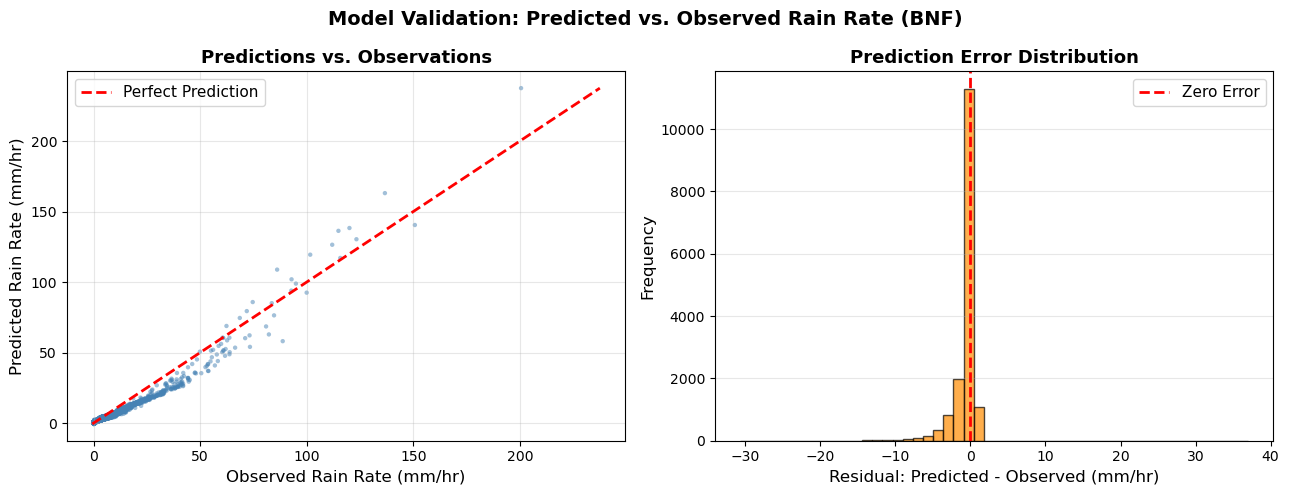

   ✓ Visualizations created


In [36]:

# ===== STEP 5: Compute Metrics =====
print("\n5. Computing performance metrics...")
mae = mean_absolute_error(targets_unscaled, preds_unscaled)
rmse = np.sqrt(mean_squared_error(targets_unscaled, preds_unscaled))
r2 = r2_score(targets_unscaled, preds_unscaled)

print(f"   MAE (Mean Absolute Error):  {mae:.3f} mm/hr")
print(f"   RMSE (Root Mean Sq Error):  {rmse:.3f} mm/hr")
print(f"   R² (Coefficient of Determ): {r2:.3f}")
print("\n   Interpretation:")
print(f"   - On average, predictions are off by {mae:.1f} mm/hr")
print(f"   - Model explains {r2*100:.1f}% of variance in rain rate")

# ===== STEP 6: Create Visualizations =====
print("\n6. Creating visualizations...")
import pandas as pd

pred_df = pd.DataFrame({
    'predicted_rainrate': preds_unscaled.flatten(),
    'true_rainrate': targets_unscaled.flatten(),
})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Validation: Predicted vs. Observed Rain Rate (BNF)', 
                fontsize=14, fontweight='bold')

# Plot 1: Predicted vs. True scatter
axes[0].scatter(pred_df['true_rainrate'], pred_df['predicted_rainrate'], 
                s=10, alpha=0.5, edgecolors='none', color='steelblue')

# Add perfect prediction line (45° diagonal)
min_val = min(pred_df['true_rainrate'].min(), pred_df['predicted_rainrate'].min())
max_val = max(pred_df['true_rainrate'].max(), pred_df['predicted_rainrate'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, 
            label='Perfect Prediction', zorder=10)

axes[0].set_xlabel('Observed Rain Rate (mm/hr)', fontsize=12)
axes[0].set_ylabel('Predicted Rain Rate (mm/hr)', fontsize=12)
axes[0].set_title('Predictions vs. Observations', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: Residuals histogram
residuals = pred_df['predicted_rainrate'] - pred_df['true_rainrate']
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')
axes[1].set_xlabel('Residual: Predicted - Observed (mm/hr)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Prediction Error Distribution', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("   ✓ Visualizations created")


**Note**: 1. The model was trained on SGP data (2025) and validated using BNF data (Nov 2025 - Apr 2026).

2. There were fewer than 10 datapoint for rain_rate above 120 mm/hr in the training data.

---

## Summary & Next Steps
We trained a neural network on labeled pairs of (radar parameters to rain rate). We tested on independent data (BNF) to show that the model learned meaningful patterns. The model achieves low MAE and explains a large fraction of rain rate variance, but struggles with heavy rain because those events are rare in the training data.

### Extending This Tutorial

**To improve the model:**
- Add more historical training data (improves heavy-rain prediction)
- Try different activation functions (tanh/sigmoid)
- Adjust learning_rate, batch_size, or dropout
- Train longer or with different data splits

:::{important}**Exercise for the Students**
Change INPUT_FEATURES and TARGET_FEATURES to match your data
:::

### References

- Ladino-Rincon, A., Nesbitt, S. W., Di Girolamo, L., Rauber, R. M., McFarquhar, G. M., & Lawson, R. P. (2025). Droplet size distribution retrieval from dual-frequency precipitation radar measurement using a deep neural network. Journal of Atmospheric and Oceanic Technology, 42(11), 1549-1566.
- Vulpiani, G., Giangrande, S., & Marzano, F. S. (2009). Rainfall estimation from polarimetric S-band radar measurements: Validation of a neural network approach. Journal of Applied Meteorology and Climatology, 48(10), 2022-2036.